In [1]:
import os
import sys
from pathlib import Path

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir/'src'))
from map2grid import *

import string
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

In [2]:
'''
    Extract power infrastructure data from OSM
    Package: osm-flex (https://github.com/osm-flex/osm-flex)
    `vietnam-latest.osm.pbf` was downloaded on 16-5-2024.
    You can skip this step and read the geopakage data in "../data/osm" directly, see the cell below.
'''
# gdf_power = load_osm_data('VNM')

# output_path="../data/osm"
# gens = import_osm_infras(gdf_power, 'power', ['plant', 'generator'], output_path)
# lines = import_osm_infras(gdf_power, 'power', ['line', 'minor_line', 'cable'], output_path)
# subs = import_osm_infras(gdf_power, 'power', ['substation'], output_path)
# trafos = import_osm_infras(gdf_power, 'power', ['transformer'], output_path)

'\n    Extract power infrastructure data from OSM\n    Package: osm-flex (https://github.com/osm-flex/osm-flex)\n    `vietnam-latest.osm.pbf` was downloaded on 16-5-2024.\n    You can skip this step and read the geopakage data in "../data/osm" directly, see the cell below.\n'

In [3]:
'''
    Read GeoPackage data directly.
'''
lines = gpd.read_file("../data/osm/line.gpkg", epsg=32648, driver='GPKG')
subs = gpd.read_file("../data/osm/substation.gpkg", epsg=32648, driver='GPKG')


c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option EPSG
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option EPSG
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


In [4]:
nodes_gdf = extract_unique_endpoints(lines)

In [5]:
updated_gdf = add_endnodes_to_lines(lines, nodes_gdf)  # Add columns node1 and node2 to lines

In [6]:
len(lines)

6735

In [7]:
subs_update = transform_osm_subs(subs, buffer_distance=200)

In [8]:
data_ways_update_osm_id, nodes_in_osm_subs = add_osm_ids_to_data(updated_gdf, subs_update)

In [9]:
data_ways_all_voltage = count_voltage_levels(data_ways_update_osm_id)

Start counting voltage levels...
Voltage levels count:
Voltage level 110 kV: 1965
Voltage level 220 kV: 933
Voltage level 500 kV: 2484
Count of rows with None voltage: 1397


In [10]:
print(len(data_ways_update_osm_id), len(data_ways_all_voltage))

6735 6779


In [11]:
data_ways_all_voltage[data_ways_all_voltage['vlevels']==2]

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,circuits,line,layer,geometry,node1,node2,geom_node1,geom_node2,Length,vlevels
21,306271499,line,220000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (695515.2856387986 1192283.81723339...,40,1204890398,"(695515.2856387986, 1192283.8172333918)","(692393.015978474, 1197337.7218878055)",8.077291,2
21,306271499,line,110000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (695515.2856387986 1192283.81723339...,40,1204890398,"(695515.2856387986, 1192283.8172333918)","(692393.015978474, 1197337.7218878055)",8.077291,2
28,306392927,line,220000,None,None,50,None,None,None,None,...,4,None,None,LINESTRING (693535.340113952 1198103.298671999...,51,52,"(693535.340113952, 1198103.2986719997)","(696953.7557265958, 1205905.58205772)",10.703178,2
28,306392927,line,110000,None,None,50,None,None,None,None,...,4,None,None,LINESTRING (693535.340113952 1198103.298671999...,51,52,"(693535.340113952, 1198103.2986719997)","(696953.7557265958, 1205905.58205772)",10.703178,2
177,400552554,line,220000,None,None,50,None,None,None,None,...,4,None,None,LINESTRING (696857.3042865028 1192133.74315324...,306259034,40,"(696975.5743583543, 1192256.6670652695)","(695515.2856387986, 1192283.8172333918)",1.665044,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5846,1267254188,line,110000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (627047.2842828373 2317043.73932735...,2489,1267254187,"(627047.2842828373, 2317043.73932735)","(626943.7514915842, 2314265.643141718)",3.238835,2
6644,1274838468,line,220000,None,None,50,None,None,None,None,...,3,None,None,LINESTRING (696953.7557265958 1205905.58205772...,52,7568,"(696953.7557265958, 1205905.58205772)","(697161.9337216325, 1206199.8892398493)",0.432591,2
6644,1274838468,line,110000,None,None,50,None,None,None,None,...,3,None,None,LINESTRING (696953.7557265958 1205905.58205772...,52,7568,"(696953.7557265958, 1205905.58205772)","(697161.9337216325, 1206199.8892398493)",0.432591,2
6648,1274838472,line,220000,None,None,50,None,None,None,None,...,4,None,None,LINESTRING (697161.9337216325 1206199.88923984...,7568,7569,"(697161.9337216325, 1206199.8892398493)","(703973.1991397288, 1208574.563984857)",9.070519,2


In [12]:
buffer_distance = 500

# Define boolean options
bool_options = {
    'plot_ways_original': True,  # Visualize all selected lines (original dataset)
    'histogram_length_busbars': True,  # Visualize the length of busbars
    'histogram_distances_between_endpoints': True,  # Visualize the distances between endpoints
    'histogram_stacked_endnodes': True,  # Visualize the number of stacked endpoints
    'plot_stacked_endnodes': True,  # Visualize all stacked endpoints on the map
}

In [13]:
# data_ways_busbar, data_busbars = delete_busbars(data_ways_all_voltage, bool_options)

Start deleting ways with type "busbar", "bay", or fully contained within substations...


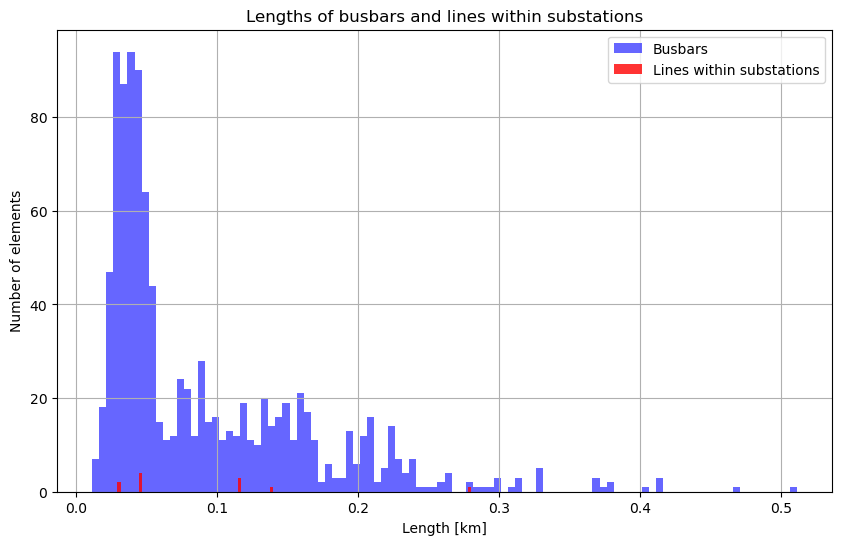

   ... there are 1043 busbars/bays in total
   ... 1043 busbars have been deleted
   ... 11 lines are entirely contained within substations
   ... 11 lines within substations have been deleted
   ... finished! (2.421 seconds) 



In [14]:
data_ways_busbar, data_busbars, data_lines_within_substations = delete_busbars(data_ways_all_voltage, subs, bool_options)

In [15]:
data_busbars

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,layer,geometry,node1,node2,geom_node1,geom_node2,Length,vlevels,busbar,within_substation
3194,1176845132,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (659723.3369255239 1319594.06005930...,1176845164,1176845164,"(659692.1155338533, 1319614.771161535)","(659692.1155338533, 1319614.771161535)",0.020401,0,True,False
3195,1176845133,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (659690.9898940896 1319585.31623525...,1176845164,1176845164,"(659692.1155338533, 1319614.771161535)","(659692.1155338533, 1319614.771161535)",0.020405,0,True,False
3196,1176845134,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (659657.4073836689 1319577.45082146...,1176845164,1176845164,"(659692.1155338533, 1319614.771161535)","(659692.1155338533, 1319614.771161535)",0.020398,0,True,False
3197,1176845135,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (659718.4910362661 1319614.42056020...,1176845164,1176845164,"(659692.1155338533, 1319614.771161535)","(659692.1155338533, 1319614.771161535)",0.020398,0,True,False
3198,1176845136,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (659685.8877175329 1319606.77046037...,1176845164,1176845164,"(659692.1155338533, 1319614.771161535)","(659692.1155338533, 1319614.771161535)",0.020395,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6722,1277767282,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (790852.0493863149 1327116.24489578...,308292618,308292618,"(790846.3807653863, 1327126.1321827967)","(790846.3807653863, 1327126.1321827967)",0.023936,0,True,False
6723,1277767283,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (790845.1854233867 1327096.93888412...,308292618,308292618,"(790846.3807653863, 1327126.1321827967)","(790846.3807653863, 1327126.1321827967)",0.046678,0,True,False
6724,1277767284,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (790831.190029656 1327109.533616501...,308292618,308292618,"(790846.3807653863, 1327126.1321827967)","(790846.3807653863, 1327126.1321827967)",0.032804,0,True,False
6725,1277767285,line,<NA>,None,None,None,None,None,None,None,...,None,LINESTRING (790857.3498092457 1327138.32536979...,308292618,308292618,"(790846.3807653863, 1327126.1321827967)","(790846.3807653863, 1327126.1321827967)",0.032794,0,True,False


In [16]:
data_ways_dc, dc_candidates = count_possible_dc(data_ways_busbar)

Start detecting lines which could be DC lines...
   ... 320 ways could potentially be a DC line.
   ... Please refer to dc_candidates for further checks.
   ... finished! (0.482 seconds) 



In [17]:
data_ways_dc

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,geometry,node1,node2,geom_node1,geom_node2,Length,vlevels,busbar,within_substation,dc_candidate
0,153608701,line,110000,None,None,50,None,None,None,None,...,LINESTRING (610714.8526952094 2315180.69968158...,153608703,1,"(610733.4323063841, 2315123.8456902527)","(609979.5121052358, 2317121.7687179567)",2.692679,1,False,False,False
1,176708144,line,110000,None,None,50,None,None,None,None,...,LINESTRING (672622.408581327 1278800.027259281...,2,1197858380,"(672622.408581327, 1278800.027259281)","(651900.1986905084, 1285465.5800645472)",27.367648,1,False,False,False
2,241194661,line,220000,None,None,50,None,None,None,None,...,LINESTRING (682154.0170507935 2315887.78970822...,4,241065371,"(682154.0170507935, 2315887.789708228)","(684823.2515457734, 2304280.3310496984)",16.135774,1,False,False,False
3,241255651,line,110000,None,None,50,None,None,None,None,...,LINESTRING (684889.726446027 2304273.826937457...,241065371,7,"(684823.2515457734, 2304280.3310496984)","(683277.9408688021, 2305527.1503790556)",2.613165,1,False,False,False
4,241255652,line,220000,None,None,50,None,None,None,None,...,LINESTRING (684710.9143918614 2304282.78396018...,241065371,549914200,"(684823.2515457734, 2304280.3310496984)","(672360.3215412779, 2304844.4158994914)",22.028022,1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5731,1277767290,line,220000,None,None,50,None,None,None,None,...,LINESTRING (791600.6835085431 1321565.29489040...,149,7649,"(791600.6835085431, 1321565.2948904098)","(790699.7446262792, 1322245.0798096587)",1.354354,1,False,False,False
5732,1277767291,line,220000,None,None,50,None,None,None,None,...,LINESTRING (789052.3155403403 1323522.17891248...,7651,1192268300,"(789052.3155403403, 1323522.1789124869)","(787030.6435399078, 1324384.3202358743)",2.542395,1,False,False,False
5733,1277767292,line,220000,None,None,50,None,None,None,None,...,LINESTRING (790486.031851314 1322420.157381075...,7650,7651,"(790486.031851314, 1322420.1573810754)","(789052.3155403403, 1323522.1789124869)",2.170255,1,False,False,False
5734,1277767293,line,220000,None,None,50,None,None,None,None,...,LINESTRING (790333.4881100592 1322619.26044402...,7652,5795,"(790333.4881100592, 1322619.2604440246)","(790666.5681916326, 1326601.4915172472)",5.943186,1,False,False,False


In [18]:
data_ways_cables = count_cables(data_ways_dc)

Start counting cables per way...
Number of rows missing both cables and circuits: 673
   ATTENTION! Both "cables" and "circuits" are missing for ID 176708144. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 241255651. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 306551278. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 306551280. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307638313. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307638315. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307638318. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307777845. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307777860. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are mis

In [19]:
data_ways_cables[['cables','circuits']]

,cables,circuits
0,6,2
1,None,1
2,6,2
3,None,1
4,6,2
...,...,...
5731,3,1
5732,3,1
5733,3,1
5734,3,1


   ... start visualizing all distances in a histogram ...


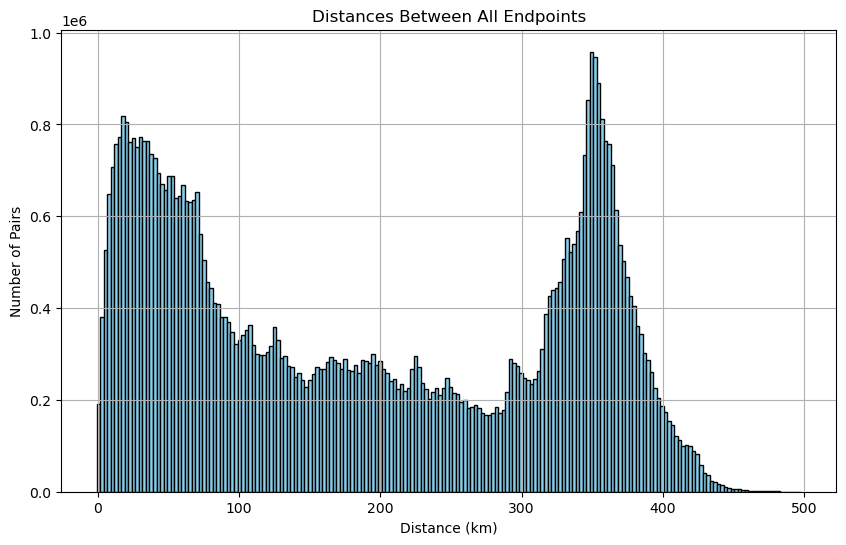

In [20]:
M = calc_distances_between_endpoints(data_ways_cables, bool_options)

Start finding all stacked endnodes...
... 8158 endnodes are stacked!
... finished! (0.994 seconds)

Reprojecting CRS from EPSG:32648 to EPSG:32648.


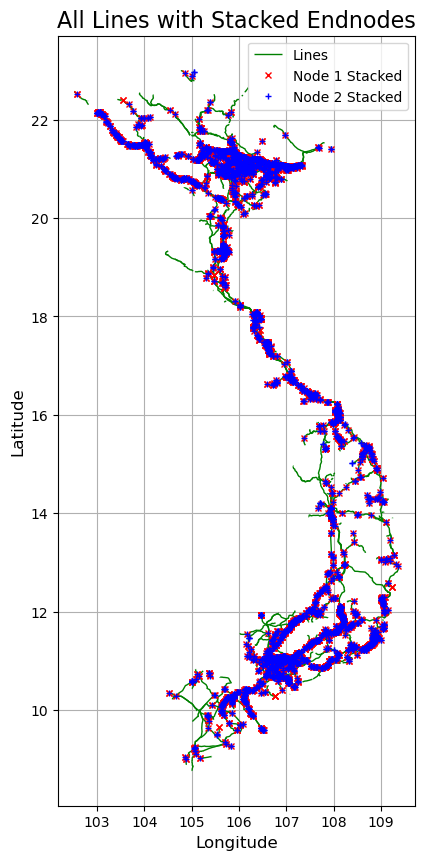

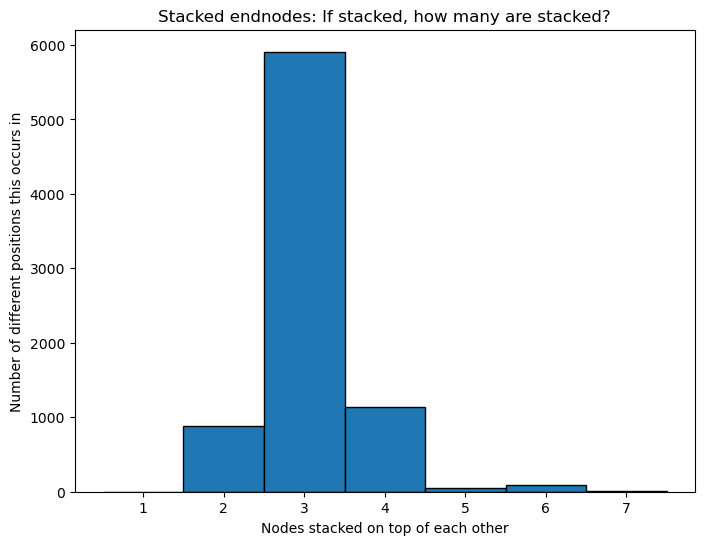

In [21]:
data_ways_stacked, nodes_stacked_pairs = calc_stacked_endnodes(data_ways_cables, M, bool_options)

In [22]:
nodes_stacked_grouped = group_nodes(nodes_stacked_pairs)

Start grouping all pairs from "pairs_input" (may take a few seconds)...
   ... 8158 nodes will be grouped together in 2734 groups,
       with an average of 2.98 nodes per group.
   ... finished! (2.335 seconds)



In [23]:
data_ways_group_stacked_nodes = group_stacked_endnodes(data_ways_cables, nodes_gdf, nodes_stacked_grouped)

Completed updating coordinates for stacked groups.


In [24]:
data_ways_final_coords = add_final_coordinates(data_ways_group_stacked_nodes)

Start adding final coordinates...
... finished!


In [25]:
data_ways_delete, data_singular_ways = delete_singular_ways(data_ways_final_coords, 'ID_node1_final', 'ID_node2_final')

Start deleting ways which have the same endpoints after grouping...
   ... 927 ways were deleted!
   ... finished! (0.016 seconds)


EPSG:4326 EPSG:4326 EPSG:4326
Start plotting original ways... (takes a few seconds)


\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects\Map2Grid\src\map2grid.py:1466: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1, label="Busbars")
\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects\Map2Grid\src\map2grid.py:1469: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1)
\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects\Map2Grid\src\map2grid.py:1478: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'kx-', color="#73d2de", linewidth=1, label="Deleted Ways")
\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects

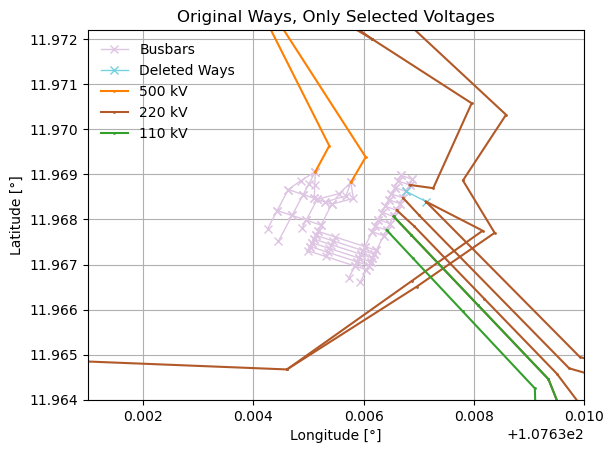

In [26]:
plot_ways_original(data_ways_delete, data_busbars, bool_options, data_singular_ways)

osm_id of the substation presented above is 1192268300.

In [30]:
def add_lineID_clone_ways(data, country_code='VN'):
    """
    Creates a unique 'LineID' for each way element in the dataset.
    If a way needs to be cloned (has more than one system), it will be duplicated, tripled, or quadrupled.
    
    Parameters:
    - data (DataFrame): Input dataset containing way elements.
    - country_code (str): Two-letter country code.
    
    Returns:
    - DataFrame: New dataset with cloned ways and 'LineID' column.
    """
    start_time = time.time()
    print('Start adding "LineID" and cloning ways...')
    
    # Fill NaN values with 1 (indicating no clone) and convert to int
    # data['systems'] = data['systems'].fillna(1).astype(int)

    # Create unique LineID prefix
    lineID_prefix = f'LINE{country_code}'
    
    # Initialize list for new data
    data_new = []
    
    # Process each row in data
    for i, row in data.iterrows():
        num_clones = int(row['circuits']) # Determine number of clones based on 'circuits' value
        base_lineID = f"{lineID_prefix}{str(i+1).zfill(4)}"  # Base LineID with four digits
        
        if num_clones == 1:
            # For rows where circuits = 1, add only the base LineID
            row['LineID'] = base_lineID
            data_new.append(row)  # Add the original row to data_new
       
        else:
            # For rows where circuits > 1, create clones as per 'circuits' 
            # and add suffixes 'a', 'b', 'c', 'd' as needed
            clones = [row.copy() for _ in range(num_clones)]
            for j, clone in enumerate(clones):
                clone['LineID'] = f"{base_lineID}{chr(97 + j)}"  # Append 'a', 'b', 'c', 'd'
                data_new.append(clone)
    
    # Convert list of expanded data back to a DataFrame
    data_new = pd.DataFrame(data_new).reset_index(drop=True)

    # Print cloning summary
    print(f"   ... {sum(row['circuits'] == 2 for _, row in data.iterrows())} ways doubled, "
          f"{sum(row['circuits'] == 3 for _, row in data.iterrows())} tripled, "
          f"{sum(row['circuits'] == 4 for _, row in data.iterrows())} quadrupled.")
    print(f'   ... finished! ({time.time() - start_time:.3f} seconds) \n')
    
    return gpd.GeoDataFrame(data_new, geometry='geometry')

In [31]:
data_ways_clone = add_lineID_clone_ways(data_ways_delete)

Start adding "LineID" and cloning ways...
   ... 390 ways doubled, 6 tripled, 19 quadrupled.
   ... finished! (5.577 seconds) 



In [32]:
table_lines = fill_line_voltage(data_ways_clone)

In [33]:
table_lines_update = table_lines.dropna(subset=['voltage'])

In [34]:
table_lines_update.head()

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,lat1_grouped,lon2_grouped,lat2_grouped,ID_node1_final,lon1_final,lat1_final,ID_node2_final,lon2_final,lat2_final,LineID
0,153608701,line,110000,None,None,50,None,None,None,None,...,NaN,609979.512105,2.317122e+06,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001a
1,153608701,line,110000,None,None,50,None,None,None,None,...,NaN,609979.512105,2.317122e+06,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001b
2,176708144,line,110000,None,None,50,None,None,None,None,...,NaN,NaN,NaN,2.0,672622.408581,1.278800e+06,1.197858e+09,651889.179899,1.285444e+06,LINEVN0002
3,241194661,line,220000,None,None,50,None,None,None,None,...,2.315888e+06,684741.069151,2.304331e+06,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003a
4,241194661,line,220000,None,None,50,None,None,None,None,...,2.315888e+06,684741.069151,2.304331e+06,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003b


In [24]:
output_dir = '../outputs'
export_data(table_lines_update, output_dir)

Start exporting data to Excel files... (may take a few seconds)
INFO: Exported lines to ../outputs/tbl_Lines_VN_500m.xlsx
INFO: Exported Nodes to ../outputs/tbl_Nodes_VN_500m.xlsx
... finished!
